# K-Means

K-Means is a clustering algorithm. 

We randomly choose `k` points in the space & assign each of the data points to one of these `k` points based the closeness.

## Plan

1. Take `K` random centroids.
2. For each point in data, find the distance (euclidean) to each of these centroids & assign that point to the nearest centroid.
4. For each cluster, calculate the mean value and Move the centroid of the cluster to this `mean` point.
5. Go to step 2.


In [27]:
import math
import statistics

class KMeans:
    def __init__(self, num_k):
        self.num_k = num_k
        # step 1
        self.K = {i: (i,i) for i in range(self.num_k)}

    def _distance(self, a, b):
        d = (a[0]-b[0])**2 + (a[1]-b[1])**2 
        return math.sqrt(d)

    def train(self, X):

        cnt = 0
        while cnt < 1000:
            # step 2
            clusters = {}
            for x in X:
                min_d = 10**10
                min_kid = None
                for kid, k in self.K.items():
                    d = self._distance(x, k)
                    if d <= min_d:
                        min_d = d
                        min_kid = kid
                        
                if min_kid not in clusters:
                    clusters[min_kid] = []
            
                clusters[min_kid].append(x)
    
    
            # step 3: means, updates Ks
            centroid_movement = 0
            for kid, points in clusters.items():
                sum_x = 0
                sum_y = 0
                for p in points:
                    sum_x += p[0]
                    sum_y += p[1]
                new_centroid = (sum_x/len(points), sum_y/len(points))
    
                # check distance b/w new & old centroid
                centroid_movement += self._distance(self.K[kid], new_centroid)
                
                self.K[kid] = new_centroid
    
            # step 4: decide and repeat
            if centroid_movement < 5:
                break

            cnt += 1

        self._clusters = clusters
        return self
            

    def predict(self, x):
        min_d = 10**10
        min_kid = None
        for kid, k in self.K.items():
            d = self._distance(x, k)
            if not min_kid or d <= min_d:
                min_d = d
                min_kid = kid
        return min_kid

### Run the model

In [161]:
import time
random.randint(1, 1000) * random.random() 

156.55121618036821

In [235]:
import random

rand_list = [random.randint(10, 100) for i in range(random.randint(1, 10))]
def rand(i):
    return random.choice(rand_list) + (random.random()*random.randint(-30, 30))

points = [(rand(i), rand(i)) for i in range(1,500)]

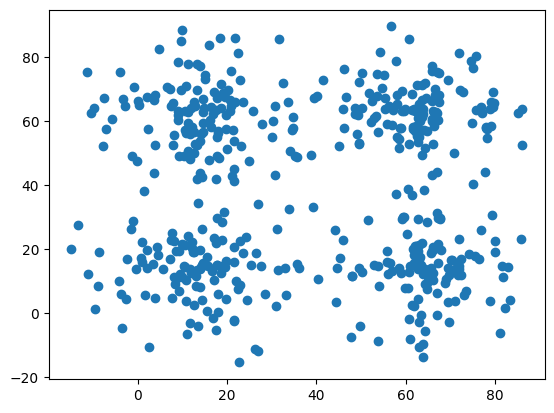

In [236]:
import matplotlib.pyplot as plt
_x_coords, _y_coords = zip(*points)
plt.scatter(_x_coords, _y_coords)

In [237]:
model = KMeans(4)
model.train(points)

In [238]:
model.K

{0: (13.113761137585, 13.1465841202948),
 1: (14.052363342356836, 61.42226955703962),
 2: (64.03130408097135, 14.083492976157466),
 3: (62.58791856047058, 63.08270248802359)}

In [239]:
model.predict((20,20))

1

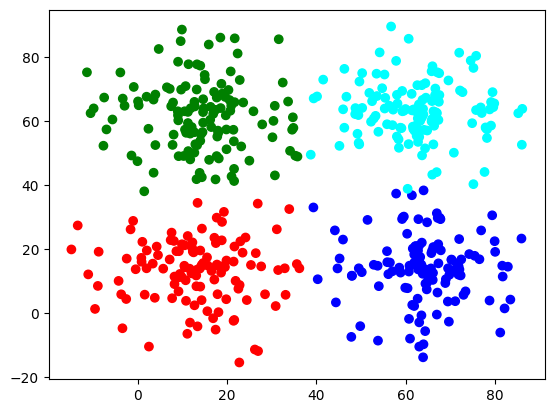

In [240]:
# Let's plot this

_colors = ['red', 'green', 'blue', 'cyan' , 'olive', 'deeppink', 'honeydew', 'magenta', 'mintcream', 'orchid', 'orange', 'skyblue', 'yellow', 'tomato']

def _get_color(point):
    for cid, ps in model._clusters.items():
        if point in ps:
            return _colors[cid]

_x_coords, _y_coords = zip(*points)
colors = [_get_color(p) for p in points]
plt.scatter(_x_coords, _y_coords, c=colors)

## Pro Tips

- How do we pick the correct value for `K`?

> Best way is to try out each K, starting 2 until we find that there is no/very-small drop in MSE in a cluster with it's centroid anymore.

- Different scales of data in X?

> Feature scaling is needed when there are data points whose range varies significantly. For example, age (1-100) and Income (1L-1Cr)

